<a href="https://colab.research.google.com/github/AbhishekCodes0615/Big_mart/blob/main/Big_mart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (8523, 12)
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999     

/tmp/ipykernel_2051/3045215383.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)
/tmp/ipykernel_2051/3045215383.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,2122.690697
1,FDW14,OUT017,1228.822479
2,NCN55,OUT010,2225.163636
3,FDQ58,OUT017,2211.720289
4,FDY38,OUT027,5043.148005



Descriptive statistics of the predicted sales:


,Item_Outlet_Sales
count,5681.000000
mean,2187.435100
std,1219.307053
min,-1216.839971
25%,1314.729217
50%,2174.612949
75%,3036.969695
max,5675.206103



Number of negative predictions: 162
There are negative predictions, which might indicate a limitation of the linear model or data issues.


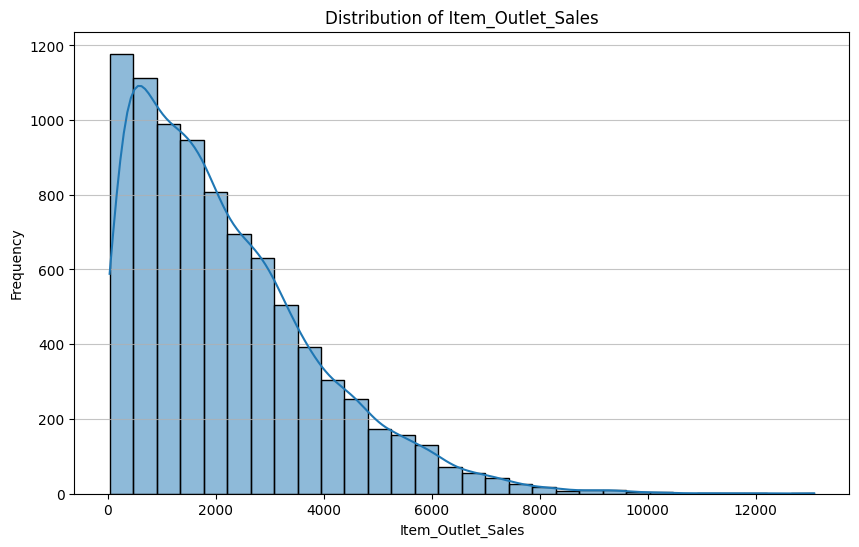

In [19]:
# ============================================
# Big Mart Sales Prediction - Linear Regression
# ============================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

data = pd.read_csv("/content/Big mart Sales/Train.csv")

print("Dataset Shape:", data.shape)
print(data.head())


outlet_size_mode_str = data['Outlet_Size'].mode()[0]

data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)
data['Outlet_Size'].fillna(outlet_size_mode_str, inplace=True)


categorical_cols = [
    'Item_Identifier',
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Identifier',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le


X = data.drop(columns='Item_Outlet_Sales')
Y = data['Item_Outlet_Sales']


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, Y_train)

print("\nModel Training Completed")


Y_pred = model.predict(X_test)

print("\nModel Evaluation:")
print("R2 Score:", r2_score(Y_test, Y_pred))
print("Mean Absolute Error:", mean_absolute_error(Y_test, Y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(Y_test, Y_pred)))


test_data = pd.read_csv("/content/Big mart Sales/Test.csv")


test_data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)

test_data['Outlet_Size'].fillna(outlet_size_mode_str, inplace=True)

for col in categorical_cols:

    test_data[col] = encoders[col].transform(test_data[col].astype(str))


test_predictions = model.predict(test_data)


output = pd.DataFrame({
    "Item_Identifier": encoders['Item_Identifier'].inverse_transform(test_data["Item_Identifier"]),
    "Outlet_Identifier": encoders['Outlet_Identifier'].inverse_transform(test_data["Outlet_Identifier"]),
    "Item_Outlet_Sales": test_predictions
})

output.to_csv("BigMart_LinearRegression_Predictions.csv", index=False)

print("\nPrediction file saved successfully!")

print("First 5 rows of the output DataFrame:")
display(output.head())

print("\nDescriptive statistics of the predicted sales:")
display(output['Item_Outlet_Sales'].describe())

negative_predictions_count = (output['Item_Outlet_Sales'] < 0).sum()
print(f"\nNumber of negative predictions: {negative_predictions_count}")
if negative_predictions_count > 0:
    print("There are negative predictions, which might indicate a limitation of the linear model or data issues.")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(Y, kde=True, bins=30)
plt.title('Distribution of Item_Outlet_Sales')
plt.xlabel('Item_Outlet_Sales')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()